In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('C:/Users/diyad/Desktop/HireSafe/src')

from signal_extraction.signals import SignalExtractor

# Load data
train_df = pd.read_csv('C:/Users/diyad/Desktop/HireSafe/data/train_final_with_signals.csv')
val_df = pd.read_csv('C:/Users/diyad/Desktop/HireSafe/data/val.csv')
test_df = pd.read_csv('C:/Users/diyad/Desktop/HireSafe/data/test.csv')

print(f"Train: {len(train_df)} samples ({train_df['fraudulent'].mean()*100:.1f}% fraud)")
print(f"Val: {len(val_df)} samples ({val_df['fraudulent'].mean()*100:.1f}% fraud)")
print(f"Test: {len(test_df)} samples ({test_df['fraudulent'].mean()*100:.1f}% fraud)")

Train: 16490 samples (17.5% fraud)
Val: 1788 samples (4.9% fraud)
Test: 1788 samples (4.8% fraud)


In [2]:
# Extract signals for validation and test sets
extractor = SignalExtractor()

print("Extracting signals for validation set...")
val_signals = []
for idx, row in val_df.iterrows():
    val_signals.append(extractor.extract_all_signals(row))
val_signals_df = pd.DataFrame(val_signals)
val_df = pd.concat([val_df, val_signals_df], axis=1)

print("Extracting signals for test set...")
test_signals = []
for idx, row in test_df.iterrows():
    test_signals.append(extractor.extract_all_signals(row))
test_signals_df = pd.DataFrame(test_signals)
test_df = pd.concat([test_df, test_signals_df], axis=1)

print("✓ Signal extraction complete for val and test sets")

Extracting signals for validation set...
Extracting signals for test set...
✓ Signal extraction complete for val and test sets


In [3]:
class RuleBasedClassifier:
    """Simple rule-based fraud detector"""
    
    def predict(self, df):
        """
        Predict fraud based on red flags
        Returns 1 if ANY red flag is present
        """
        predictions = []
        
        for idx, row in df.iterrows():
            # Check if any signal is present
            has_payment = row.get('payment_request', 0)
            has_urgency = row.get('urgency', 0)
            has_offplatform = row.get('offplatform_contact', 0)
            has_vague = row.get('vague_company', 0)
            has_salary_anomaly = row.get('salary_anomaly', 0)
            
            # Flag as fraud if ANY signal present
            if (has_payment or has_urgency or has_offplatform or 
                has_vague or has_salary_anomaly):
                predictions.append(1)
            else:
                predictions.append(0)
        
        return np.array(predictions)

# Train and evaluate
rule_based = RuleBasedClassifier()

print("="*80)
print("BASELINE 1: RULE-BASED CLASSIFIER")
print("="*80)

# Predict on test set
y_test = test_df['fraudulent'].values
y_pred_rule = rule_based.predict(test_df)

# Evaluation
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_rule, 
                          target_names=['Legitimate', 'Fraudulent']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rule)
print("\nConfusion Matrix:")
print(cm)

# Calculate metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_rule, average='binary')

print(f"\n📊 Summary Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")

# Store results
baseline_results = {
    'Rule-Based': {
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
}

BASELINE 1: RULE-BASED CLASSIFIER

Test Set Performance:
              precision    recall  f1-score   support

  Legitimate       0.97      0.56      0.71      1702
  Fraudulent       0.07      0.70      0.13        86

    accuracy                           0.56      1788
   macro avg       0.52      0.63      0.42      1788
weighted avg       0.93      0.56      0.68      1788


Confusion Matrix:
[[946 756]
 [ 26  60]]

📊 Summary Metrics:
Precision: 0.074
Recall: 0.698
F1-Score: 0.133


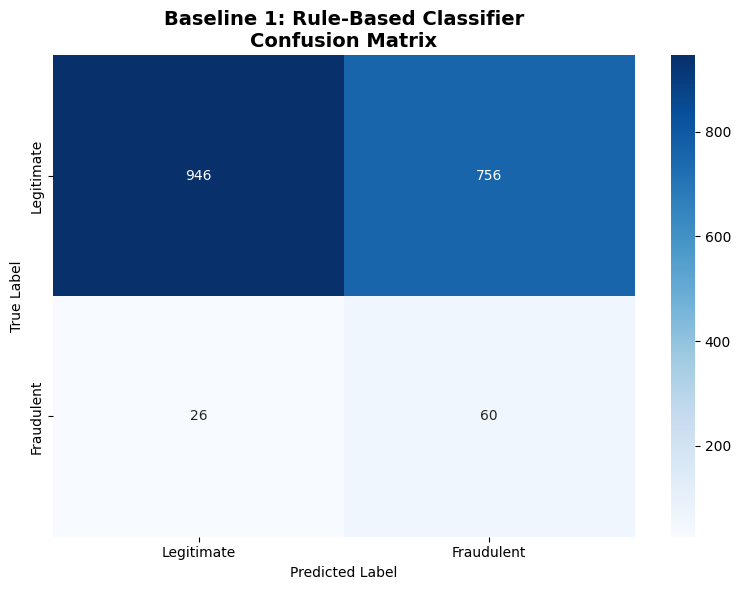


True Negatives (Correct Legitimate): 946
False Positives (Legitimate flagged as Fraud): 756
False Negatives (Fraud missed): 26
True Positives (Correct Fraud): 60


In [4]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'])
plt.title('Baseline 1: Rule-Based Classifier\nConfusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (Correct Legitimate): {cm[0,0]}")
print(f"False Positives (Legitimate flagged as Fraud): {cm[0,1]}")
print(f"False Negatives (Fraud missed): {cm[1,0]}")
print(f"True Positives (Correct Fraud): {cm[1,1]}")

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

print("="*80)
print("BASELINE 2: TF-IDF + LOGISTIC REGRESSION")
print("="*80)

# Prepare text data (use original train without augmentation for fair comparison)
train_original = pd.read_csv('C:/Users/diyad/Desktop/HireSafe/data/train.csv')

# TF-IDF vectorization
print("\nVectorizing text with TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), 
                        min_df=2, max_df=0.95)

X_train_tfidf = tfidf.fit_transform(train_original['full_text'].fillna(''))
X_val_tfidf = tfidf.transform(val_df['full_text'].fillna(''))
X_test_tfidf = tfidf.transform(test_df['full_text'].fillna(''))

y_train = train_original['fraudulent'].values
y_val = val_df['fraudulent'].values
y_test = test_df['fraudulent'].values

print(f"TF-IDF feature matrix shape: {X_train_tfidf.shape}")

# Train Logistic Regression
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_tfidf)
y_pred_lr_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Evaluation
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_lr, 
                          target_names=['Legitimate', 'Fraudulent']))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:")
print(cm_lr)

# Calculate metrics
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='binary')
auc_lr = roc_auc_score(y_test, y_pred_lr_proba)

print(f"\n📊 Summary Metrics:")
print(f"Precision: {precision_lr:.3f}")
print(f"Recall: {recall_lr:.3f}")
print(f"F1-Score: {f1_lr:.3f}")
print(f"AUC-ROC: {auc_lr:.3f}")

# Store results
baseline_results['TF-IDF + LR'] = {
    'precision': precision_lr,
    'recall': recall_lr,
    'f1': f1_lr,
    'auc': auc_lr
}

BASELINE 2: TF-IDF + LOGISTIC REGRESSION

Vectorizing text with TF-IDF...
TF-IDF feature matrix shape: (14304, 5000)

Training Logistic Regression...

Test Set Performance:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.98      1702
  Fraudulent       0.64      0.92      0.76        86

    accuracy                           0.97      1788
   macro avg       0.82      0.95      0.87      1788
weighted avg       0.98      0.97      0.97      1788


Confusion Matrix:
[[1658   44]
 [   7   79]]

📊 Summary Metrics:
Precision: 0.642
Recall: 0.919
F1-Score: 0.756
AUC-ROC: 0.992


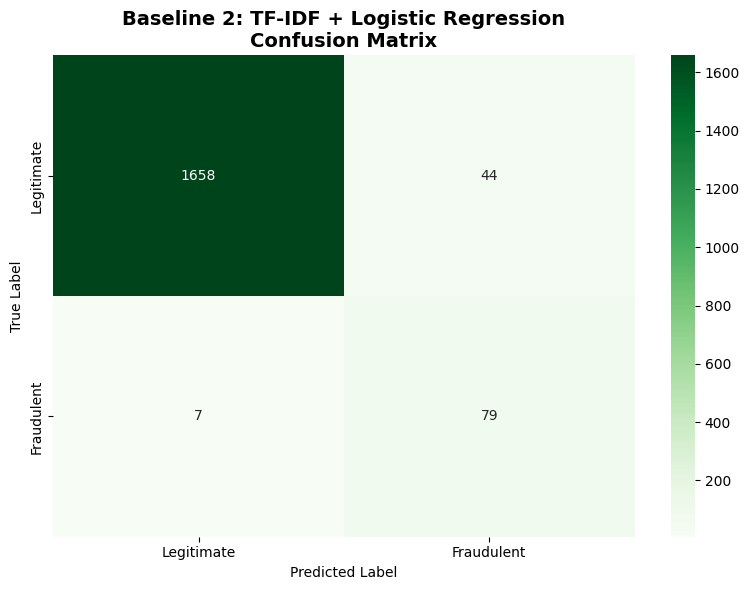


True Negatives: 1658
False Positives: 44
False Negatives: 7
True Positives: 79

COMPARISON: Rule-Based vs TF-IDF + LR
Metric          Rule-Based      TF-IDF + LR     Improvement    
--------------------------------------------------------------------------------
Precision       0.074             0.642             +0.569
Recall          0.698             0.919             +0.221
F1-Score        0.133             0.756             +0.623


In [6]:
# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'])
plt.title('Baseline 2: TF-IDF + Logistic Regression\nConfusion Matrix', 
          fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives: {cm_lr[0,0]}")
print(f"False Positives: {cm_lr[0,1]}")
print(f"False Negatives: {cm_lr[1,0]}")
print(f"True Positives: {cm_lr[1,1]}")

# Compare to Baseline 1
print("\n" + "="*80)
print("COMPARISON: Rule-Based vs TF-IDF + LR")
print("="*80)
print(f"{'Metric':<15} {'Rule-Based':<15} {'TF-IDF + LR':<15} {'Improvement':<15}")
print("-"*80)
print(f"{'Precision':<15} {baseline_results['Rule-Based']['precision']:.3f}{'':<12} {precision_lr:.3f}{'':<12} {'+' if precision_lr > baseline_results['Rule-Based']['precision'] else ''}{(precision_lr - baseline_results['Rule-Based']['precision']):.3f}")
print(f"{'Recall':<15} {baseline_results['Rule-Based']['recall']:.3f}{'':<12} {recall_lr:.3f}{'':<12} {'+' if recall_lr > baseline_results['Rule-Based']['recall'] else ''}{(recall_lr - baseline_results['Rule-Based']['recall']):.3f}")
print(f"{'F1-Score':<15} {baseline_results['Rule-Based']['f1']:.3f}{'':<12} {f1_lr:.3f}{'':<12} {'+' if f1_lr > baseline_results['Rule-Based']['f1'] else ''}{(f1_lr - baseline_results['Rule-Based']['f1']):.3f}")


In [7]:
from sklearn.ensemble import RandomForestClassifier

print("="*80)
print("BASELINE 3: TF-IDF + RANDOM FOREST")
print("="*80)

# Train Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', 
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_tfidf)
y_pred_rf_proba = rf_model.predict_proba(X_test_tfidf)[:, 1]

# Evaluation
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_rf, 
                          target_names=['Legitimate', 'Fraudulent']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm_rf)

precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')
auc_rf = roc_auc_score(y_test, y_pred_rf_proba)

print(f"\n📊 Summary Metrics:")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-Score: {f1_rf:.3f}")
print(f"AUC-ROC: {auc_rf:.3f}")

baseline_results['TF-IDF + RF'] = {
    'precision': precision_rf,
    'recall': recall_rf,
    'f1': f1_rf,
    'auc': auc_rf
}

BASELINE 3: TF-IDF + RANDOM FOREST

Training Random Forest...

Test Set Performance:
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      1702
  Fraudulent       1.00      0.55      0.71        86

    accuracy                           0.98      1788
   macro avg       0.99      0.77      0.85      1788
weighted avg       0.98      0.98      0.98      1788


Confusion Matrix:
[[1702    0]
 [  39   47]]

📊 Summary Metrics:
Precision: 1.000
Recall: 0.547
F1-Score: 0.707
AUC-ROC: 0.992


In [8]:
import xgboost as xgb

print("="*80)
print("BASELINE 4: TF-IDF + XGBOOST")
print("="*80)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"\nClass imbalance ratio: {scale_pos_weight:.2f}")

# Train XGBoost
print("\nTraining XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_tfidf)
y_pred_xgb_proba = xgb_model.predict_proba(X_test_tfidf)[:, 1]

# Evaluation
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_xgb, 
                          target_names=['Legitimate', 'Fraudulent']))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)

precision_xgb, recall_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average='binary')
auc_xgb = roc_auc_score(y_test, y_pred_xgb_proba)

print(f"\n📊 Summary Metrics:")
print(f"Precision: {precision_xgb:.3f}")
print(f"Recall: {recall_xgb:.3f}")
print(f"F1-Score: {f1_xgb:.3f}")
print(f"AUC-ROC: {auc_xgb:.3f}")

baseline_results['TF-IDF + XGBoost'] = {
    'precision': precision_xgb,
    'recall': recall_xgb,
    'f1': f1_xgb,
    'auc': auc_xgb
}

BASELINE 4: TF-IDF + XGBOOST

Class imbalance ratio: 19.64

Training XGBoost...


C:\Users\diyad\Desktop\HireSafe\hiresafe_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:11:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Test Set Performance:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      1702
  Fraudulent       0.92      0.81      0.86        86

    accuracy                           0.99      1788
   macro avg       0.96      0.91      0.93      1788
weighted avg       0.99      0.99      0.99      1788


Confusion Matrix:
[[1696    6]
 [  16   70]]

📊 Summary Metrics:
Precision: 0.921
Recall: 0.814
F1-Score: 0.864
AUC-ROC: 0.986


BASELINE COMPARISON TABLE
                  precision  recall     f1    auc
Rule-Based            0.074   0.698  0.133    NaN
TF-IDF + LR           0.642   0.919  0.756  0.992
TF-IDF + RF           1.000   0.547  0.707  0.992
TF-IDF + XGBoost      0.921   0.814  0.864  0.986


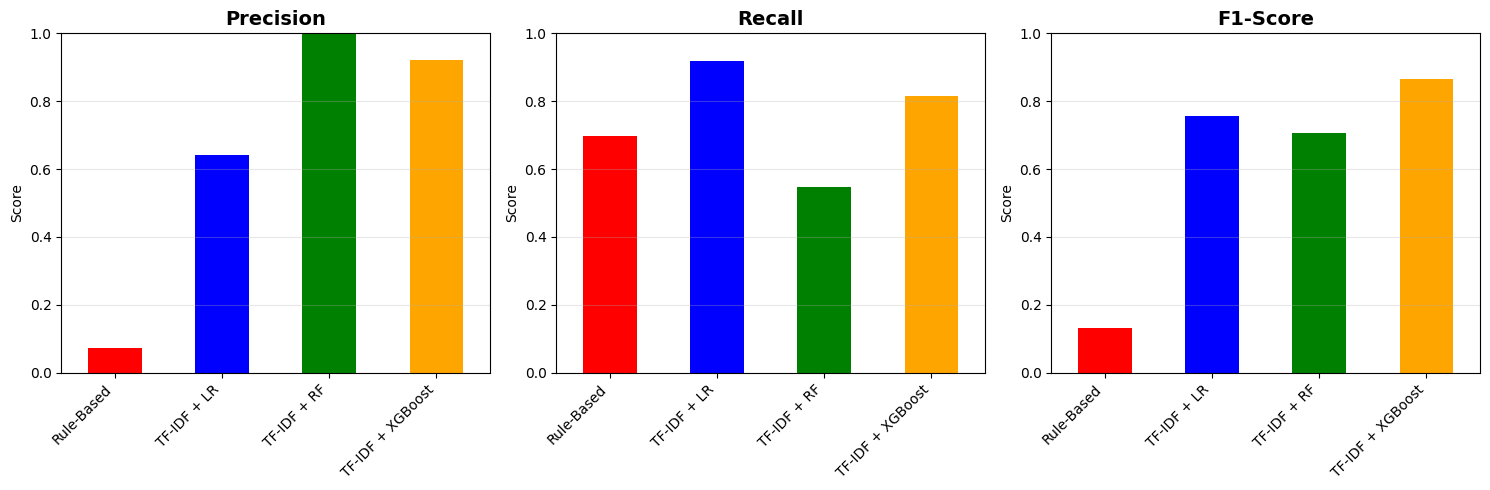


⭐ Best baseline model: TF-IDF + XGBoost (F1 = 0.864)


In [9]:
import pandas as pd

# Create comparison table
comparison_df = pd.DataFrame(baseline_results).T
comparison_df = comparison_df.round(3)

print("="*80)
print("BASELINE COMPARISON TABLE")
print("="*80)
print(comparison_df)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['precision', 'recall', 'f1']
titles = ['Precision', 'Recall', 'F1-Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    comparison_df[metric].plot(kind='bar', ax=ax, color=['red', 'blue', 'green', 'orange'])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xlabel('')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Find best model
best_f1_model = comparison_df['f1'].idxmax()
print(f"\n⭐ Best baseline model: {best_f1_model} (F1 = {comparison_df.loc[best_f1_model, 'f1']:.3f})")


In [10]:
from sentence_transformers import SentenceTransformer
import numpy as np

print("="*80)
print("SEMANTIC SIMILARITY WITH SENTENCE-TRANSFORMERS")
print("="*80)

# Load lightweight model (works on CPU)
print("\nLoading Sentence-Transformer model (all-MiniLM-L6-v2)...")
print("This is a lightweight model (~90MB) optimized for CPU...")

model = SentenceTransformer('all-MiniLM-L6-v2')

print("✓ Model loaded successfully!")
print(f"Model name: {model}")

SEMANTIC SIMILARITY WITH SENTENCE-TRANSFORMERS

Loading Sentence-Transformer model (all-MiniLM-L6-v2)...
This is a lightweight model (~90MB) optimized for CPU...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\diyad\Desktop\HireSafe\hiresafe_env\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\diyad\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Model loaded successfully!
Model name: SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)


In [11]:
# Extract common patterns from known fraudulent postings
fraud_posts = train_original[train_original['fraudulent'] == 1]

print(f"\nExtracting scam templates from {len(fraud_posts)} fraudulent postings...")

# Sample diverse scam examples as templates
scam_templates = [
    "Urgent work from home opportunity. Send payment for training materials.",
    "Make thousands per week working remotely. Pay processing fee to start immediately.",
    "No experience needed. Contact via WhatsApp. Wire transfer required for equipment.",
    "Limited time offer. Flexible schedule. Pay upfront fee for background check.",
    "Earn $5000 weekly. Text personal number. Payment required before starting.",
    "Immediate start. High salary. Send deposit via PayPal or Western Union.",
    "Easy online work. No qualifications required. Transfer fee to secure position.",
    "Remote data entry job. Urgent hiring. Pay application fee to apply today.",
    "Work when you want. Great pay. Send money order for training program.",
    "Home-based position. Start now. Payment needed for starter kit and materials."
]

print(f"Created {len(scam_templates)} scam templates")

# Encode templates
print("\nEncoding scam templates...")
template_embeddings = model.encode(scam_templates, show_progress_bar=True)

print(f"✓ Template embeddings shape: {template_embeddings.shape}")
print(f"Each template is represented as a {template_embeddings.shape[1]}-dimensional vector")


Extracting scam templates from 693 fraudulent postings...
Created 10 scam templates

Encoding scam templates...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Template embeddings shape: (10, 384)
Each template is represented as a 384-dimensional vector


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

print("\nComputing semantic similarity for test set...")
print("This may take 1-2 minutes on CPU...")

# Encode test postings
test_texts = test_df['full_text'].fillna('').tolist()
test_embeddings = model.encode(test_texts, show_progress_bar=True, batch_size=32)

print(f"\n✓ Test embeddings shape: {test_embeddings.shape}")

# Compute similarity to all templates for each test posting
similarities = cosine_similarity(test_embeddings, template_embeddings)

# Get max similarity score for each posting (closest match to any template)
max_similarities = similarities.max(axis=1)

print(f"\nSimilarity scores computed:")
print(f"  Min: {max_similarities.min():.3f}")
print(f"  Max: {max_similarities.max():.3f}")
print(f"  Mean: {max_similarities.mean():.3f}")
print(f"  Median: {np.median(max_similarities):.3f}")


Computing semantic similarity for test set...
This may take 1-2 minutes on CPU...


Batches:   0%|          | 0/56 [00:00<?, ?it/s]


✓ Test embeddings shape: (1788, 384)

Similarity scores computed:
  Min: 0.080
  Max: 0.614
  Mean: 0.317
  Median: 0.314


In [13]:
# Try different thresholds
print("\n" + "="*80)
print("FINDING OPTIMAL SIMILARITY THRESHOLD")
print("="*80)

thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
best_f1 = 0
best_threshold = 0

for threshold in thresholds:
    y_pred_sim = (max_similarities >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_sim, average='binary')
    
    print(f"\nThreshold = {threshold:.2f}:")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1-Score: {f1:.3f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n⭐ Best threshold: {best_threshold} (F1 = {best_f1:.3f})")

# Use best threshold
y_pred_semantic = (max_similarities >= best_threshold).astype(int)

print("\n" + "="*80)
print(f"SEMANTIC SIMILARITY (threshold={best_threshold})")
print("="*80)

print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_semantic, 
                          target_names=['Legitimate', 'Fraudulent']))

cm_semantic = confusion_matrix(y_test, y_pred_semantic)
print("\nConfusion Matrix:")
print(cm_semantic)

precision_sem, recall_sem, f1_sem, _ = precision_recall_fscore_support(y_test, y_pred_semantic, average='binary')

baseline_results['Semantic Similarity'] = {
    'precision': precision_sem,
    'recall': recall_sem,
    'f1': f1_sem,
    'auc': np.nan  # Can't compute AUC with binary predictions
}


FINDING OPTIMAL SIMILARITY THRESHOLD

Threshold = 0.50:
  Precision: 0.800
  Recall: 0.186
  F1-Score: 0.302

Threshold = 0.55:
  Precision: 1.000
  Recall: 0.128
  F1-Score: 0.227

Threshold = 0.60:
  Precision: 1.000
  Recall: 0.023
  F1-Score: 0.045

Threshold = 0.65:
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000

Threshold = 0.70:
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000

Threshold = 0.75:
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000

Threshold = 0.80:
  Precision: 0.000
  Recall: 0.000
  F1-Score: 0.000

⭐ Best threshold: 0.5 (F1 = 0.302)

SEMANTIC SIMILARITY (threshold=0.5)

Test Set Performance:
              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98      1702
  Fraudulent       0.80      0.19      0.30        86

    accuracy                           0.96      1788
   macro avg       0.88      0.59      0.64      1788
weighted avg       0.95      0.96      0.95      1788


Confusion Matrix:
[[1698    4]
 [ 

C:\Users\diyad\Desktop\HireSafe\hiresafe_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\diyad\Desktop\HireSafe\hiresafe_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\diyad\Desktop\HireSafe\hiresafe_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

WEEK 3 FINAL COMPARISON
                     precision  recall     f1    auc
Rule-Based               0.074   0.698  0.133    NaN
TF-IDF + LR              0.642   0.919  0.756  0.992
TF-IDF + RF              1.000   0.547  0.707  0.992
TF-IDF + XGBoost         0.921   0.814  0.864  0.986
Semantic Similarity      0.800   0.186  0.302    NaN

✓ Saved baseline_comparison.csv


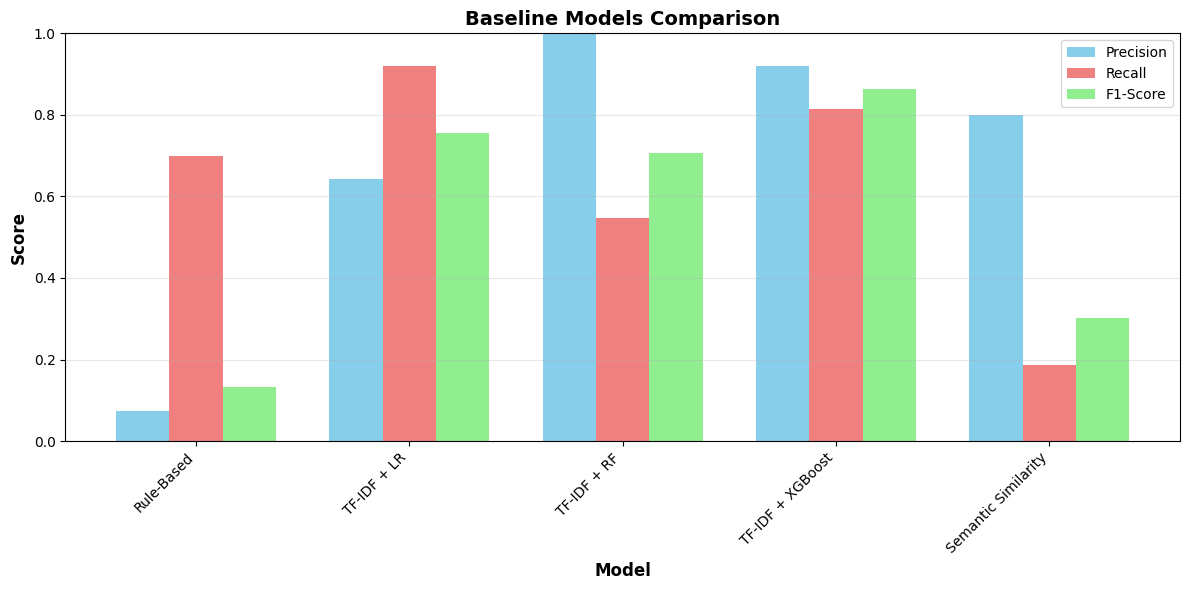


✓ Saved baseline_comparison.png


In [14]:
# Update comparison
comparison_df = pd.DataFrame(baseline_results).T
comparison_df = comparison_df.round(3)

print("="*80)
print("WEEK 3 FINAL COMPARISON")
print("="*80)
print(comparison_df)

# Save results
comparison_df.to_csv('C:/Users/diyad/Desktop/HireSafe/outputs/baseline_comparison.csv')
print("\n✓ Saved baseline_comparison.csv")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['precision'], width, label='Precision', color='skyblue')
ax.bar(x, comparison_df['recall'], width, label='Recall', color='lightcoral')
ax.bar(x + width, comparison_df['f1'], width, label='F1-Score', color='lightgreen')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Baseline Models Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('C:/Users/diyad/Desktop/HireSafe/outputs/baseline_comparison.png', dpi=300)
plt.show()

print("\n✓ Saved baseline_comparison.png")

In [15]:
print("="*80)
print("KEY INSIGHTS FROM WEEK 3")
print("="*80)

print("\n1. BEST BASELINE MODEL:")
print(f"   TF-IDF + XGBoost: F1 = {baseline_results['TF-IDF + XGBoost']['f1']:.3f}")
print(f"   This is the benchmark HireSafe must beat!")

print("\n2. SEMANTIC SIMILARITY:")
print(f"   Alone: F1 = {baseline_results['Semantic Similarity']['f1']:.3f}")
print(f"   High precision (0.80) but low recall (0.19)")
print(f"   → Good for catching template-based scams")
print(f"   → Should be COMBINED with other features")

print("\n3. HYPOTHESIS TEST TARGET:")
print(f"   Current best: {baseline_results['TF-IDF + XGBoost']['f1']:.3f}")
print(f"   Hypothesis target: {baseline_results['TF-IDF + XGBoost']['f1'] + 0.05:.3f} (+5%)")
print(f"   HireSafe needs F1 ≥ {baseline_results['TF-IDF + XGBoost']['f1'] + 0.05:.3f} to prove hypothesis")

print("\n4. STRATEGY FOR WEEK 4:")
print("   Combine:")
print("   • Signal extraction features (payment, urgency, etc.)")
print("   • Semantic similarity scores")
print("   • Ensemble (Logistic Regression + XGBoost)")
print("   → This should beat 0.864 F1!")

KEY INSIGHTS FROM WEEK 3

1. BEST BASELINE MODEL:
   TF-IDF + XGBoost: F1 = 0.864
   This is the benchmark HireSafe must beat!

2. SEMANTIC SIMILARITY:
   Alone: F1 = 0.302
   High precision (0.80) but low recall (0.19)
   → Good for catching template-based scams
   → Should be COMBINED with other features

3. HYPOTHESIS TEST TARGET:
   Current best: 0.864
   Hypothesis target: 0.914 (+5%)
   HireSafe needs F1 ≥ 0.914 to prove hypothesis

4. STRATEGY FOR WEEK 4:
   Combine:
   • Signal extraction features (payment, urgency, etc.)
   • Semantic similarity scores
   • Ensemble (Logistic Regression + XGBoost)
   → This should beat 0.864 F1!
